In [132]:
import datetime as dt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import APSIMGraphHelpers as AGH
import GraphHelpers as GH
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
import matplotlib.dates as mdates
import MathsUtilities as MUte
import shlex # package to construct the git command to subprocess format
import subprocess 
import xmltodict, json
import sqlite3
from scipy.optimize import basinhopping
from scipy.optimize import dual_annealing
from skopt import gp_minimize
%matplotlib inline

In [133]:
con = sqlite3.connect(r'C:\GitHubRepos\ApsimX\Tests\Validation\Wheat\Wheat.db')
DailyReport = pd.read_sql("Select * from DailyReport",con)

In [134]:
Simulations = pd.read_sql("Select * from _Simulations",con)
Simulations.set_index('ID',inplace=True)
Simulations.sort_index(inplace=True)
Simulations.sort_index(inplace=True, axis=1)

In [135]:
Factors = pd.read_sql("Select * from _Factors", con)
Factors.set_index('SimulationID',drop=False,inplace=True)
Factors.sort_index(inplace=True)
Factors.sort_index(inplace=True,axis=1)

In [137]:
Observed = pd.read_sql("Select * from Observed",con).dropna(axis=1,how='all')
Observed.loc[:,'SimulationName'] = [Simulations.loc[x,'Name'] for x in Observed.SimulationID]
Observed.set_index(['SimulationName','Clock.Today'],drop=False,inplace=True)
Observed.sort_index(inplace=True)
Observed.sort_index(inplace=True,axis=1)

In [138]:
HarvestPred = pd.read_sql("Select * from HarvestReport",con).dropna(axis=1,how='all')
HarvestPred.loc[:,'SimulationName'] = [Simulations.loc[x,'Name'] for x in HarvestPred.SimulationID]
HarvestPred.set_index(['SimulationName','Clock.Today'],drop=False,inplace=True)
HarvestPred.sort_index(inplace=True)
HarvestPred.sort_index(inplace=True,axis=1)

con.close()

In [139]:
HarvestObs = Observed.loc[Observed.loc[:,'Wheat.Phenology.CurrentStageName']=='HarvestRipe',:].dropna(axis=1,how='all').dropna(axis=0,how='all')

In [140]:
HarvVars = ['Wheat.AboveGround.N',
'Wheat.AboveGround.Nconc',
'Wheat.AboveGround.Wt',
'Wheat.Ear.N',
'Wheat.Ear.Nconc',
'Wheat.Ear.Wt',
'Wheat.Grain.N',
'Wheat.Grain.NConc',
'Wheat.Grain.Number',
'Wheat.Grain.Protein',
'Wheat.Grain.Size',
'Wheat.Grain.Wt',
'Wheat.Leaf.Dead.Wt',
'Wheat.Leaf.Dead.N',
'Wheat.Leaf.Live.N',
'Wheat.Leaf.Live.Wt',
'Wheat.Leaf.N',
'Wheat.Leaf.StemPopulation',
'Wheat.Leaf.Wt',
'Wheat.Phenology.CAMP.TSHS',
'Wheat.Phenology.EmergenceDAS',
'Wheat.Phenology.FinalLeafNumber',
'Wheat.Phenology.FlagLeafDAS',
'Wheat.Phenology.FloweringDAS',
'Wheat.Phenology.HeadingDAS',
'Wheat.Phenology.MaturityDAS',
'Wheat.Phenology.TerminalSpikeletDAS',
'Wheat.Spike.HeadNumber',
'Wheat.Spike.N',
'Wheat.Spike.Wt',
'Wheat.Stem.N',
'Wheat.Stem.NConc',
'Wheat.Stem.Wt']

for x in HarvVars:
    print (str(HarvestObs.loc[:,x].count()) + "  " + x)

76  Wheat.AboveGround.N
10  Wheat.AboveGround.Nconc
685  Wheat.AboveGround.Wt
20  Wheat.Ear.N
16  Wheat.Ear.Nconc
123  Wheat.Ear.Wt
160  Wheat.Grain.N
157  Wheat.Grain.NConc
283  Wheat.Grain.Number
747  Wheat.Grain.Protein
438  Wheat.Grain.Size
928  Wheat.Grain.Wt
61  Wheat.Leaf.Dead.Wt
4  Wheat.Leaf.Dead.N
137  Wheat.Leaf.Height
6  Wheat.Leaf.Live.N
27  Wheat.Leaf.Live.Wt
4  Wheat.Leaf.N
114  Wheat.Leaf.StemPopulation
54  Wheat.Leaf.Wt
136  Wheat.Phenology.CAMP.TSHS
4277  Wheat.Phenology.EmergenceDAS
898  Wheat.Phenology.FinalLeafNumber
1342  Wheat.Phenology.FlagLeafDAS
1638  Wheat.Phenology.FloweringDAS
5638  Wheat.Phenology.HeadingDAS
373  Wheat.Phenology.MaturityDAS
87  Wheat.Phenology.TerminalSpikeletDAS
336  Wheat.Spike.HeadNumber
4  Wheat.Spike.N
90  Wheat.Spike.Wt
20  Wheat.Stem.N
16  Wheat.Stem.NConc
124  Wheat.Stem.Wt


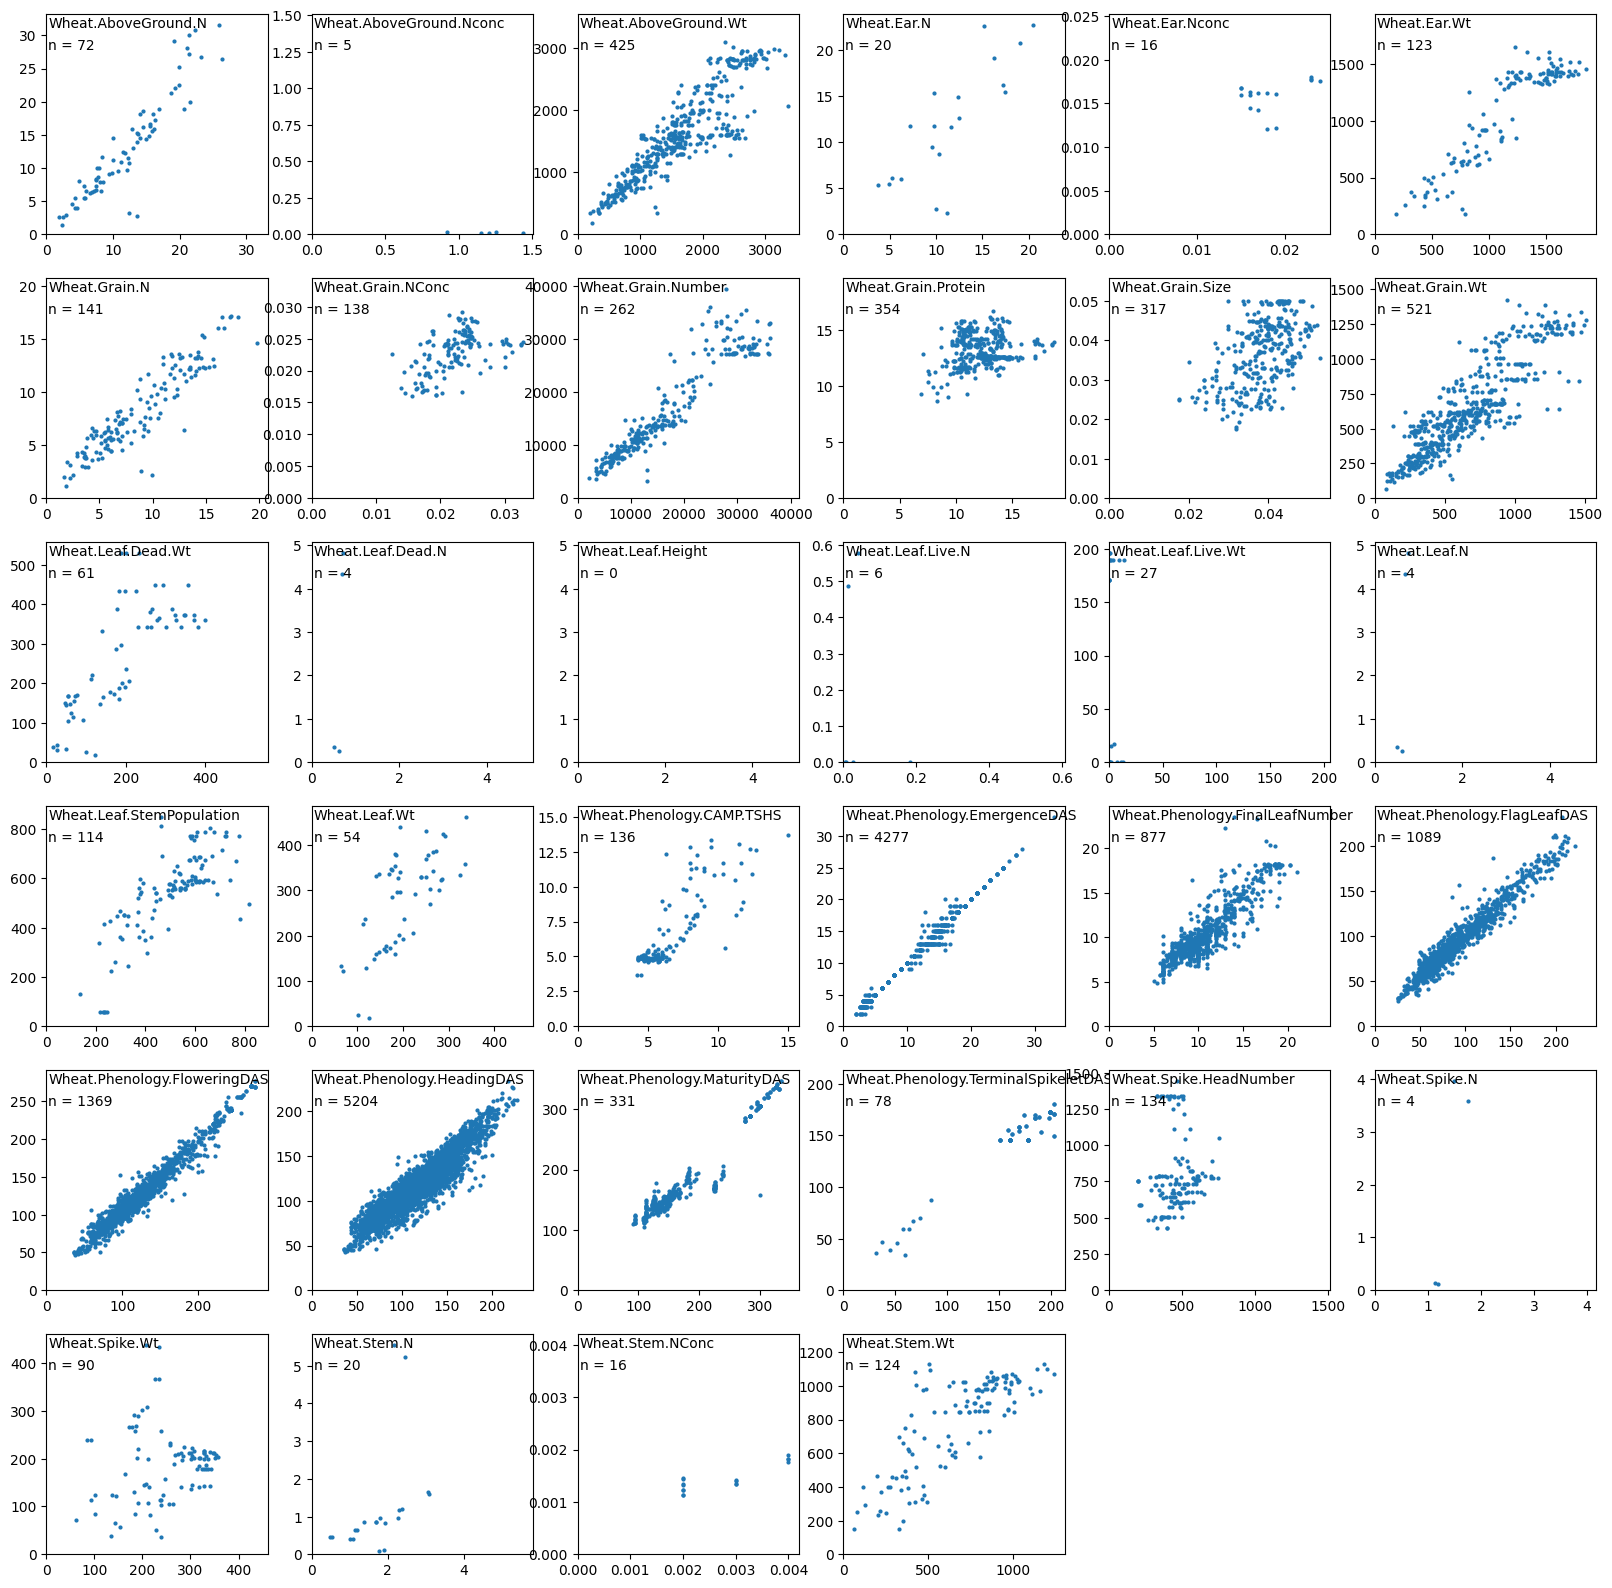

In [141]:
HarvGraphs =  plt.figure(figsize=(20,20))
pos=1
for var in HarvVars:
    ax = HarvGraphs.add_subplot(6,6,pos)
    obsPred = pd.DataFrame(HarvestObs.loc[:,var].copy())
    obsPred.columns = ['obs']
    obsPred.index = obsPred.index.get_level_values(0)
    for s in obsPred.index:
        try:
            obsPred.loc[s,'pred'] = HarvestPred.loc[s,var].values[0]
        except:
            obsPred.loc[s,'pred'] = np.nan
    obsPred.dropna(inplace=True)
    plt.plot(obsPred.obs,obsPred.pred,'o',ms = 2)
    plt.text(0.01,0.99,var,transform=ax.transAxes,horizontalalignment='left', verticalalignment='top')
    n = len(obsPred.obs)
    plt.text(0.01,0.89,'n = '+ str(n),transform=ax.transAxes,horizontalalignment='left', verticalalignment='top')
    amax = 1
    if len(obsPred.pred.dropna())>0:
        axmax = max(obsPred.obs.max(),obsPred.pred.max())
    plt.ylim(0,axmax*1.05)
    plt.xlim(0,axmax*1.05)
    
    pos+=1

In [11]:
HarvestObs = Observed.loc[Observed.loc[:,'Wheat.Phenology.CurrentStageName'] == 'HarvestRipe',:].copy()
HarvestObs.dropna(axis=1,how='all',inplace=True)
HarvestObs.dropna(axis=0,how='all',inplace=True)
HarvestObs.index = HarvestObs.index.get_level_values(0)

In [142]:
dailyObs = ['Clock.Today',
'Soil]Water.Volumetric',
'Wheat.AboveGround.N',
'Wheat.AboveGround.Nconc',
'Wheat.AboveGround.Wt',
'Wheat.DaysAfterSowing',
'Wheat.Ear.N',
'Wheat.Ear.Nconc',
'Wheat.Ear.Wt',
'Wheat.Grain.N',
'Wheat.Grain.NConc',
'Wheat.Grain.Number',
'Wheat.Grain.Protein',
'Wheat.Grain.Size',
'Wheat.Grain.Wt',
'Wheat.Leaf.CoverGreen',
'Wheat.Leaf.CoverTotal',
'Wheat.Leaf.Dead.N',
'Wheat.Leaf.Dead.NConc',
'Wheat.Leaf.Dead.Wt',
'Wheat.Leaf.Height',
'Wheat.Leaf.LAI',
'Wheat.Leaf.Ligules',
'Wheat.Leaf.Live.N',
'Wheat.Leaf.Live.NConc',
'Wheat.Leaf.Live.StorageWt',
'Wheat.Leaf.Live.Wt',
'Wheat.Leaf.N',
'Wheat.Leaf.SpecificArea',
'Wheat.Leaf.SpecificAreaCanopy',
'Wheat.Leaf.StemNumberPerPlant',
'Wheat.Leaf.StemPopulation',
'Wheat.Leaf.Tips',
'Wheat.Leaf.Wt',
'Wheat.Phenology.CAMP.TSHS',
'Wheat.Phenology.CurrentStageName',
'Wheat.Phenology.EmergenceDAS',
'Wheat.Phenology.FinalLeafNumber',
'Wheat.Phenology.FlagLeafDAS',
'Wheat.Phenology.FloweringDAS',
'Wheat.Phenology.HaunStage',
'Wheat.Phenology.HeadingDAS',
'Wheat.Phenology.MaturityDAS',
'Wheat.Phenology.TerminalSpikeletDAS',
'Wheat.Phenology.Zadok.Stage',
'Wheat.Population',
'Wheat.Spike.HeadNumber',
'Wheat.Spike.N',
'Wheat.Spike.NConc',
'Wheat.Spike.Live.StorageWt',
'Wheat.Spike.Wt',
'Wheat.Stem.N',
'Wheat.Stem.NConc',
'Wheat.Stem.Live.StorageWt',
'Wheat.Stem.Wt',
'Wheat.Phenology.CAMP.VSHS',
'Wheat.Structure.TotalStemPopn',
'sum(ObservedLayers.SWmm)',
'sum(Soil.Water.MM)',
'(Wheat.Leaf.Transpiration+ISoilWater.Es+MicroClimate.PrecipitationInterception)']

In [143]:
IsHarvest = Observed.loc[:,'Wheat.Phenology.CurrentStageName'] == 'HarvestRipe' 
LacksClock = Observed.loc[:,'Clock.Today'].isnull()

In [159]:
Observed.loc[:,dailyObs]

KeyError: "['Soil]Water.Volumetric', 'sum(Soil.Water.MM)', '(Wheat.Leaf.Transpiration+ISoilWater.Es+MicroClimate.PrecipitationInterception)'] not in index"

In [130]:
LacksClock & IsHarvest

0         True
1         True
2         True
3         True
4         True
         ...  
39947    False
39948    False
39949    False
39950    False
39951    False
Length: 39952, dtype: bool

In [102]:
Observed.loc[Observed.iloc[:,2].isnull(),'Wheat.Phenology.CurrentStageName']

0        HarvestRipe
1        HarvestRipe
2        HarvestRipe
3        HarvestRipe
4        HarvestRipe
            ...     
26180           None
26181           None
26182           None
26183           None
26184           None
Name: Wheat.Phenology.CurrentStageName, Length: 12712, dtype: object